In [36]:
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pylab as plt

In [13]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [15]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [16]:
df_clean = df.drop("CustomerID", axis=1)
df_clean

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


* Data Visualization

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

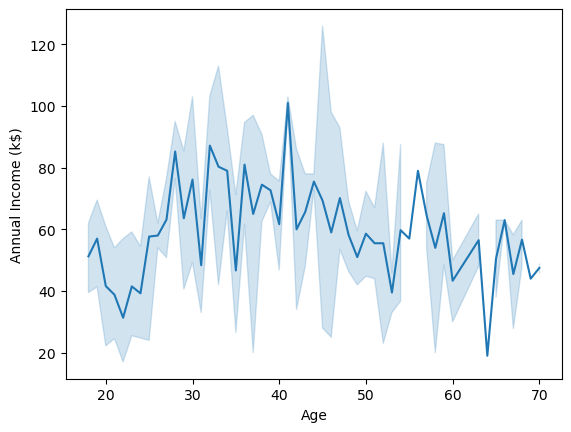

In [ ]:
sns.lineplot(x=df["Age"], y=df["Annual Income (k$)"])

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

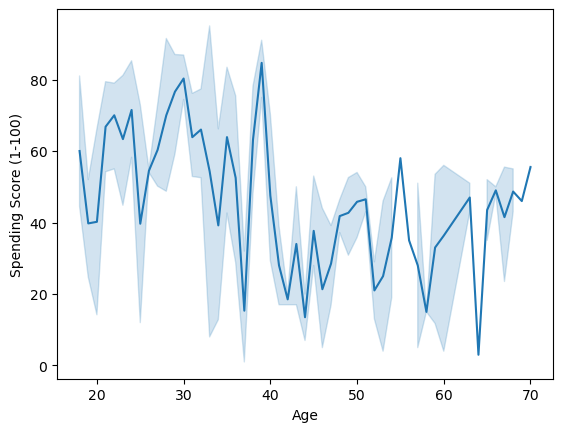

In [50]:
sns.lineplot(x=df["Age"], y=df["Spending Score (1-100)"])

In [17]:
# Scaling

scaler = StandardScaler()

df_scal = scaler.fit_transform(df_clean)

In [20]:
# dimensionality reduciton using PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(df_scal)

<Axes: >

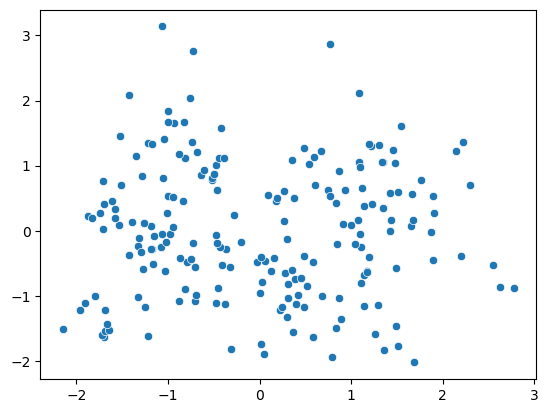

In [22]:
# Visualization

sns.scatterplot(x = pca_data[:, 0], y=pca_data[:, 1])

* Finding K Value

In [23]:
# Elbow method

wcss = []

for k in range(1, 10):
    Kmeans = KMeans(n_clusters=k)
    Kmeans.fit(pca_data)
    wcss.append(Kmeans.inertia_)

<Axes: >

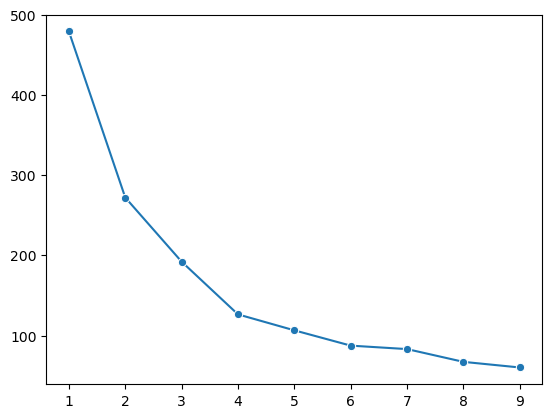

In [26]:
sns.lineplot(x=range(1, 10), y = wcss, marker="o")

In [29]:
# Silhouette Score

ss = []

for k in range(2, 10):
    Kmeans = KMeans(n_clusters=k)
    labels = Kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    ss.append(score)

<Axes: >

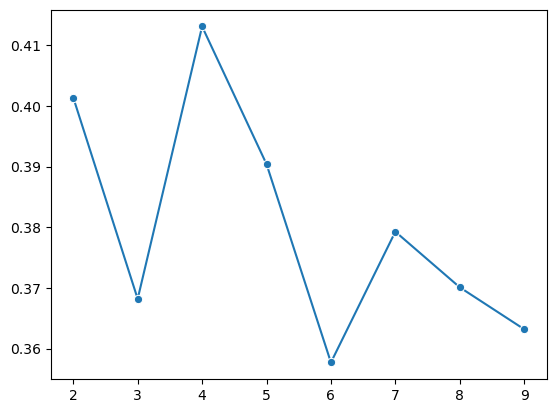

In [ ]:
sns.lineplot(x=range(2, 10), y=ss, marker = "o")

<Axes: >

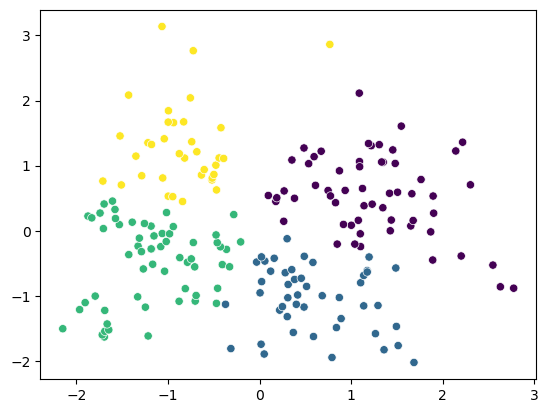

In [31]:
# KMeans

Kmeans = KMeans(n_clusters=4, random_state=42)
labels = Kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y = pca_data[:, 1], c = labels)